In [2]:
import pandas as pd
import seaborn as sns

df=pd.read_csv('iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [14]:
x=df[['sepal_length','sepal_width','petal_length','petal_width']]
x



,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [13]:
y=df[['species']]
y

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
...,...
145,virginica
146,virginica
147,virginica
148,virginica


In [8]:

from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
scaled_data=pd.DataFrame(scalar.fit_transform(x))
scaled_data





,0,1,2,3
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


<Axes: >

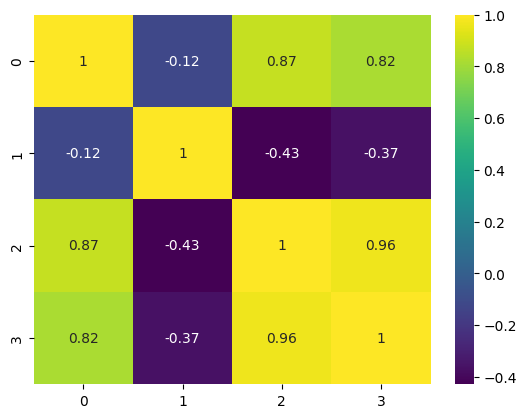

In [6]:
sns.heatmap(scaled_data.corr(),cmap='viridis',annot=True)

In [7]:
from sklearn.decomposition import PCA
pca=PCA(n_components=4)
pca.fit(scaled_data)
x_pca=pca.transform(scaled_data)
x_pca=pd.DataFrame(x_pca,columns=['pc1','pc2','pc3','pc4'])
x_pca

,pc1,pc2,pc3,pc4
0,-2.264703,0.480027,0.127706,-0.024168
1,-2.080961,-0.674134,0.234609,-0.103007
2,-2.364229,-0.341908,-0.044201,-0.028377
3,-2.299384,-0.597395,-0.091290,0.065956
4,-2.389842,0.646835,-0.015738,0.035923
...,...,...,...,...
145,1.870503,0.386966,-0.256274,-0.389257
146,1.564580,-0.896687,0.026371,-0.220192
147,1.521170,0.269069,-0.180178,-0.119171
148,1.372788,1.011254,-0.933395,-0.026129


<Axes: >

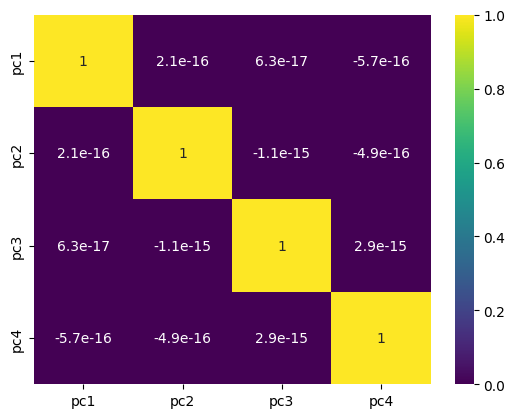

In [9]:
#x_pca.head()

sns.heatmap(x_pca.corr(),cmap='viridis', annot=True)



In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_pca,y,test_size=0.2,random_state=3)



In [15]:
x_train

,pc1,pc2,pc3,pc4
14,-2.198741,1.860057,0.472901,-0.194732
24,-2.227163,0.137254,-0.117994,0.270140
139,1.852045,0.676128,0.012672,-0.195195
58,0.927902,0.032226,0.596169,0.029880
8,-2.334640,-1.115328,-0.145077,0.026859
...,...,...,...,...
107,2.302439,0.420066,0.651706,0.238041
21,-2.207013,0.924121,-0.159865,-0.059597
0,-2.264703,0.480027,0.127706,-0.024168
131,2.304928,2.626323,0.493474,0.211676


In [16]:
y_train

,species
14,setosa
24,setosa
139,virginica
58,versicolor
8,setosa
...,...
107,virginica
21,setosa
0,setosa
131,virginica


In [17]:
x_test

,pc1,pc2,pc3,pc4
47,-2.394376,-0.386247,-0.139468,0.048835
3,-2.299384,-0.597395,-0.091290,0.065956
31,-1.831595,0.423695,0.270467,-0.239870
25,-1.951846,-0.625619,0.305641,-0.043562
15,-2.262215,2.686284,-0.030527,-0.050534
118,3.310696,0.017781,0.703305,-0.045189
89,0.283477,-1.329325,-0.089410,-0.008906
6,-2.444029,0.047644,-0.335470,0.036776
103,1.440151,-0.046988,-0.163630,0.235770
65,0.875407,0.509064,0.503511,-0.104944


In [18]:
y_test

,species
47,setosa
3,setosa
31,setosa
25,setosa
15,setosa
118,virginica
89,versicolor
6,setosa
103,virginica
65,versicolor


In [20]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(x_train,y_train)

y_pred=dtc.predict(x_test)


In [19]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

1.0